<a href="https://colab.research.google.com/github/siddhipawar65-hub/RISC-V-Processor/blob/main/THERMAL%20IMAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving woman_thermographic_image.jpg to woman_thermographic_image (2).jpg


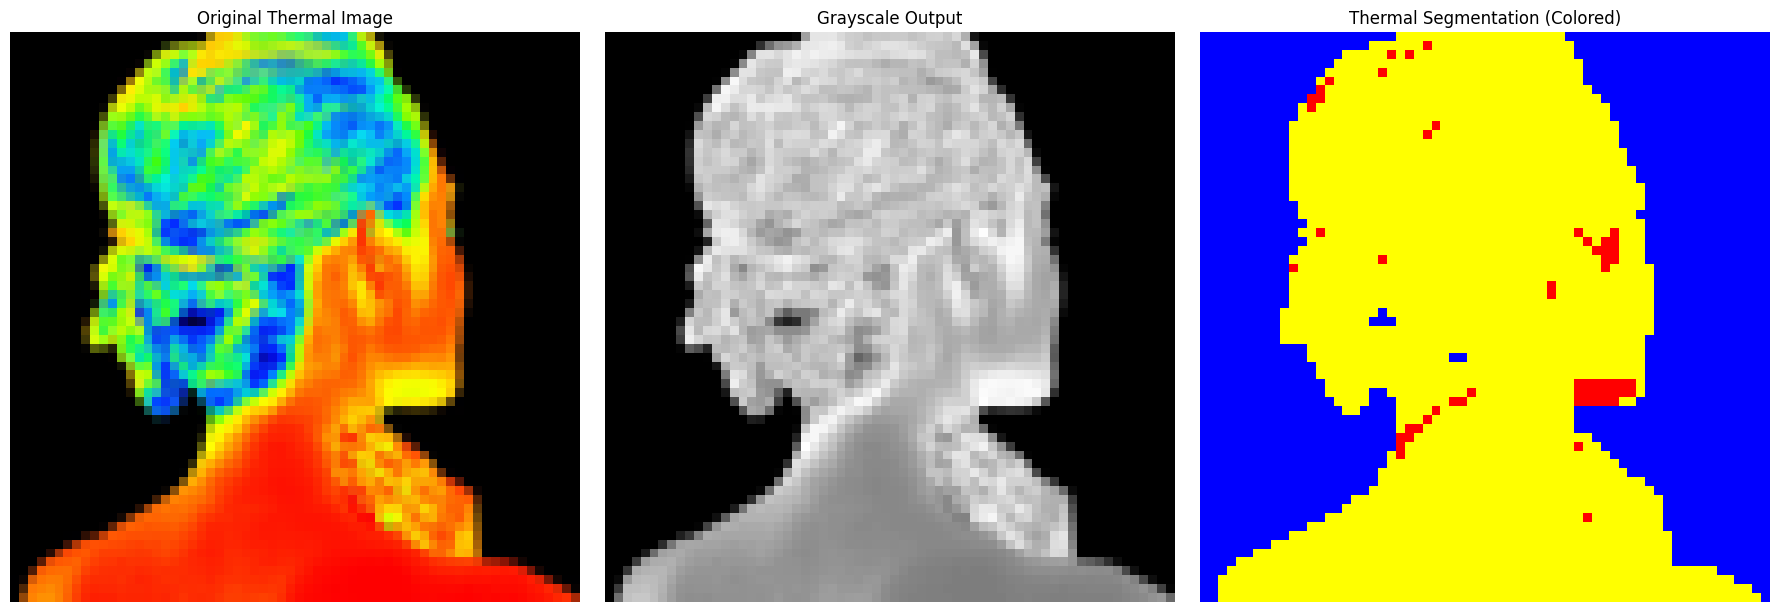

In [6]:
# Step 1: Import libraries
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# Step 2: Upload image (Colab or Jupyter)
try:
    from google.colab import files
    uploaded = files.upload()
    original_path = list(uploaded.keys())[0]
except ImportError:
    original_path = input("Enter path to thermal image: ")

# Step 3: Load image
img = Image.open(original_path).convert("RGB")
img_resized = img.resize((64, 64))
pixels = np.array(img_resized)

# Step 4: Grayscale
gray_img = np.uint8(np.mean(pixels, axis=2))

# Step 5: Thermal segmentation with color
seg_img = np.zeros((gray_img.shape[0], gray_img.shape[1], 3), dtype=np.uint8)

# Thresholds for cold/mid/hot
cold_thresh = 80
hot_thresh = 160

# Cold → Blue
seg_img[gray_img < cold_thresh] = [0, 0, 255]
# Mid → Yellow
seg_img[(gray_img >= cold_thresh) & (gray_img < hot_thresh)] = [255, 255, 0]
# Hot → Red
seg_img[gray_img >= hot_thresh] = [255, 0, 0]

# Step 6: Save outputs (optional)
Image.fromarray(gray_img).save("output_gray.png")
Image.fromarray(seg_img).save("output_seg_colored.png")

# Step 7: Plotting
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_resized)
ax[0].set_title("Original Thermal Image")
ax[0].axis('off')

ax[1].imshow(gray_img, cmap='gray')
ax[1].set_title("Grayscale Output")
ax[1].axis('off')

ax[2].imshow(seg_img)
ax[2].set_title("Thermal Segmentation (Colored)")
ax[2].axis('off')

plt.tight_layout()
plt.show()
